# Tech Challenge - Classificação de Risco em Câncer de Mama

Este notebook apresenta uma solução inicial de classificação de risco para apoio ao diagnóstico de câncer de mama, utilizando técnicas de machine learning e SHAP para explicabilidade. A proposta não é substituir a decisão médica, mas apoiar a triagem com mais agilidade e transparência.

**Dataset utilizado:** `dataset/breast-cancer.csv` (mesma base sugerida no enunciado).


## Objetivo da Análise

O foco deste trabalho é classificar exames em duas classes: **benigno** e **maligno**. O fluxo adotado contempla exploração de dados, pré-processamento, análise de correlação, treino de mais de um modelo, avaliação por métricas de classificação e interpretação com feature importance e SHAP.


In [1]:
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
os.environ["XDG_CACHE_HOME"] = "/tmp"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import shap

sns.set_style("whitegrid")
np.random.seed(42)


## Carregamento dos Dados

Nesta etapa, a base é carregada para verificação de formato, colunas e tipos de dados. Essa leitura inicial é essencial para reduzir riscos de interpretação incorreta antes da modelagem.


In [2]:
df = pd.read_csv("dataset/breast-cancer.csv")

print("Dimensoes da base:", df.shape)
display(df.head())
print("\nTipos de dados:")
print(df.dtypes)


Dimensoes da base: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Tipos de dados:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
con

## Exploração Inicial

A análise exploratória descritiva e visual permite entender a distribuição das variáveis e o equilíbrio das classes. Como se trata de um problema de saúde, a proporção entre casos **malignos** e **benignos** recebe atenção especial.


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


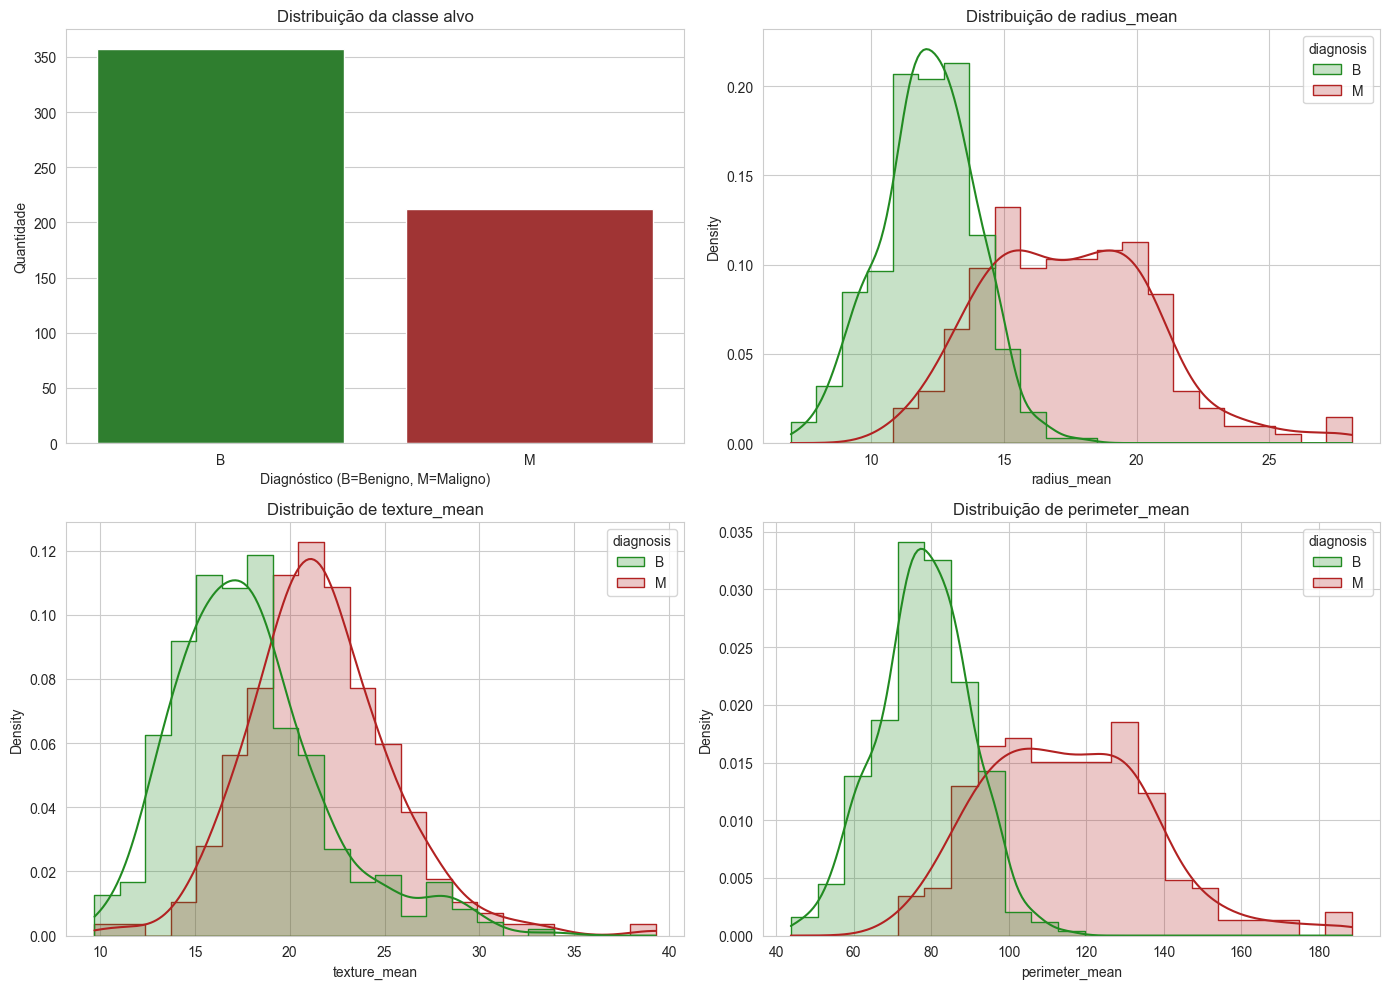

In [3]:
display(df.describe().T)

palette_diag = {"B": "forestgreen", "M": "firebrick"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="diagnosis", order=["B", "M"], ax=axes[0, 0], palette=palette_diag)
axes[0, 0].set_title("Distribuição da classe alvo")
axes[0, 0].set_xlabel("Diagnóstico (B=Benigno, M=Maligno)")
axes[0, 0].set_ylabel("Quantidade")

selected_features = ["radius_mean", "texture_mean", "perimeter_mean"]
for ax, col in zip(axes.flat[1:], selected_features):
    sns.histplot(
        data=df,
        x=col,
        hue="diagnosis",
        hue_order=["B", "M"],
        palette=palette_diag,
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(f"Distribuição de {col}")

plt.tight_layout()
plt.show()


## Limpeza e Pré-processamento

Nesta base, não foram identificados valores ausentes; ainda assim, foi estruturado um pipeline com imputação e padronização para manter robustez no fluxo. A coluna `id` foi removida por representar apenas identificação de amostras, sem valor clínico direto.

A coluna `diagnosis` é categórica e foi convertida para formato numérico: **benigno = 0** e **maligno = 1**.


In [4]:
print("Valores ausentes totais:", int(df.isna().sum().sum()))
print("Duplicados:", int(df.duplicated().sum()))

df_model = df.copy()

if "id" in df_model.columns:
    df_model = df_model.drop(columns=["id"])

y = df_model["diagnosis"].map({"B": 0, "M": 1})
X = df_model.drop(columns=["diagnosis"])

print("\nFormato de X:", X.shape)
print("Formato de y:", y.shape)
print("\nProporcao das classes (0=Benigno, 1=Maligno):")
print(y.value_counts(normalize=True).sort_index())


Valores ausentes totais: 0
Duplicados: 0

Formato de X: (569, 30)
Formato de y: (569,)

Proporcao das classes (0=Benigno, 1=Maligno):
diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64


## Análise de Correlação

A combinação de correlação com mapa de calor facilita a leitura das relações entre variáveis.


Top variáveis mais correlacionadas com o diagnóstico (em valor absoluto):


,correlacao_com_diagnosis
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360
concavity_worst,0.659610


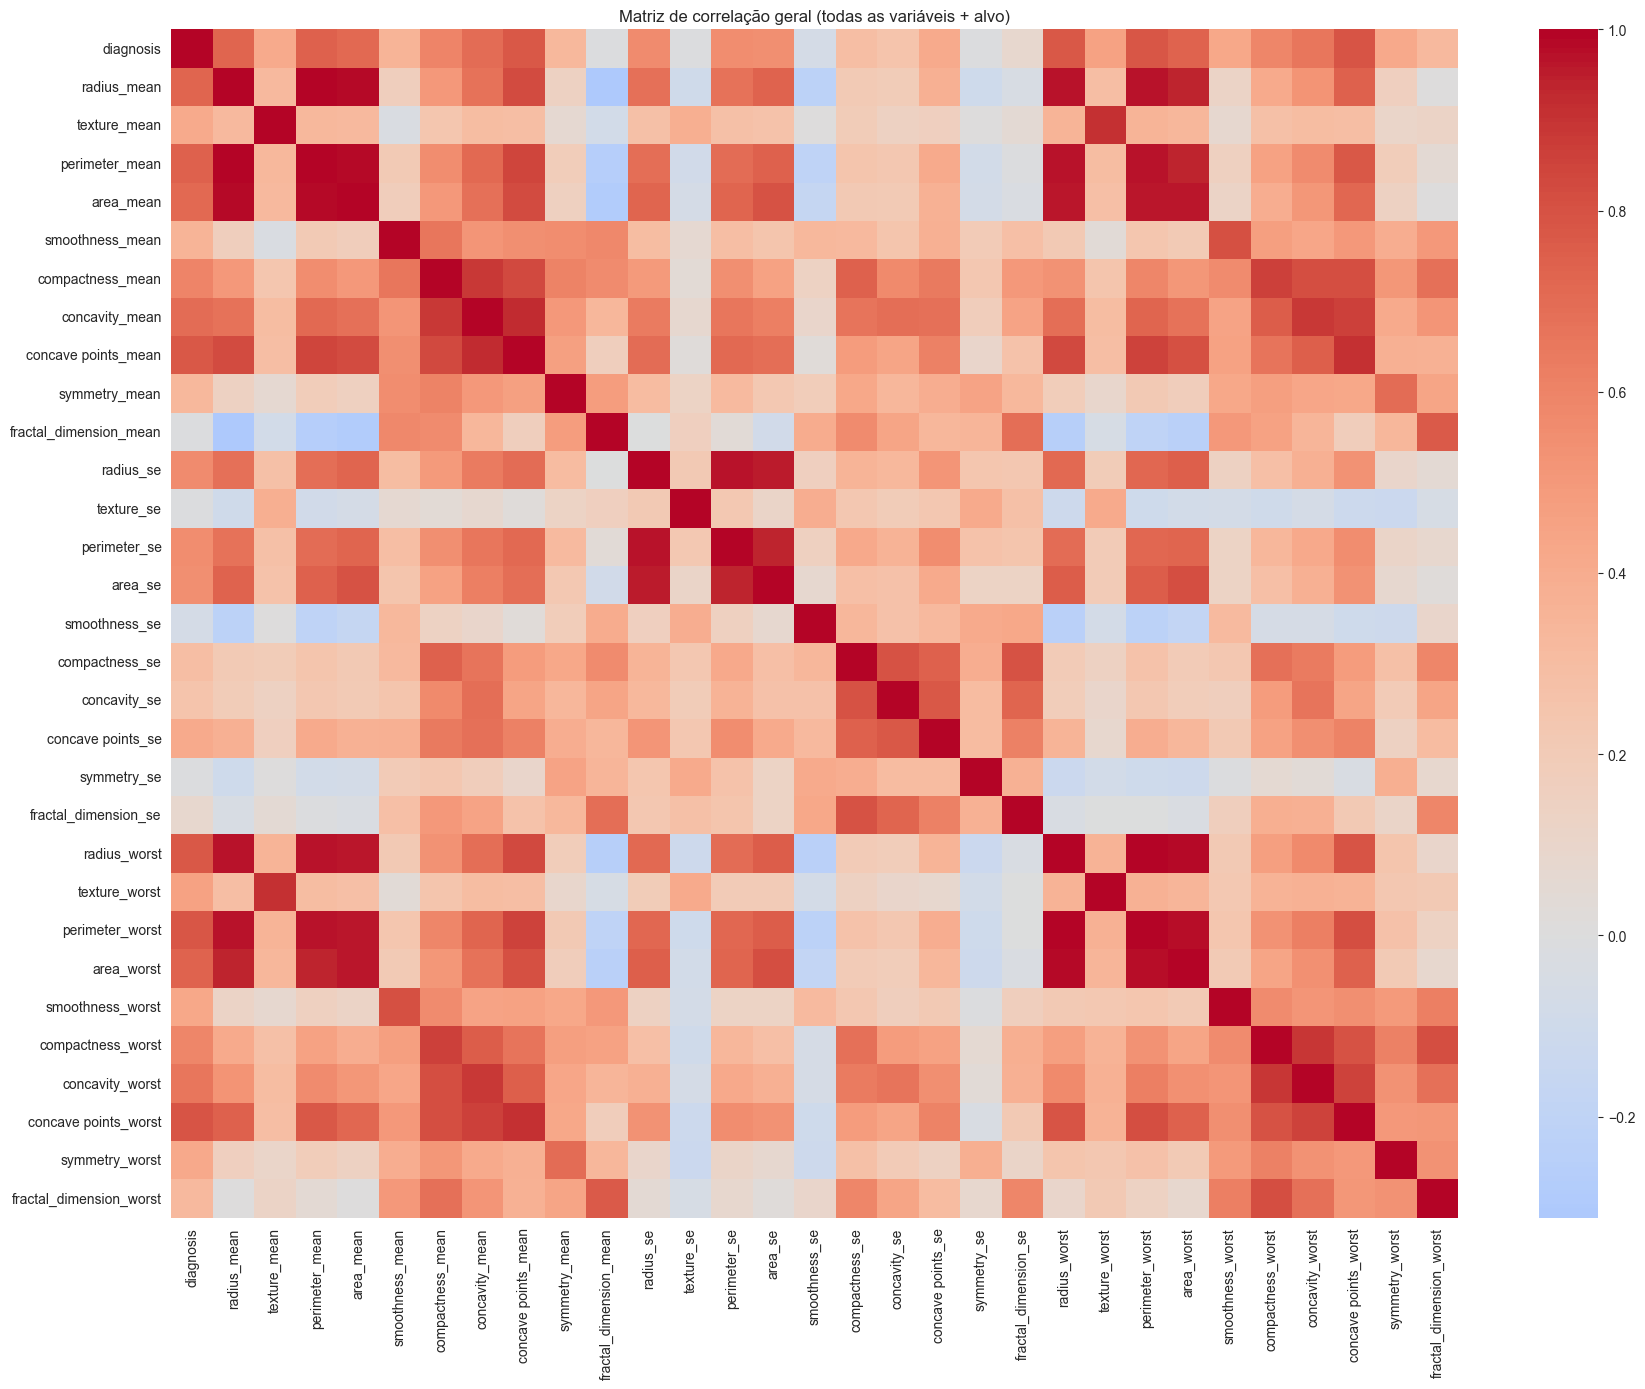

In [5]:
corr_df = df_model.copy()
corr_df["diagnosis"] = corr_df["diagnosis"].map({"B": 0, "M": 1})

corr_matrix = corr_df.corr(numeric_only=True)
target_corr = corr_matrix["diagnosis"].drop("diagnosis").sort_values(key=np.abs, ascending=False)

print("Top variáveis mais correlacionadas com o diagnóstico (em valor absoluto):")
display(target_corr.head(12).to_frame("correlacao_com_diagnosis"))

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlação geral (todas as variáveis + alvo)")
plt.tight_layout()
plt.show()


## Separação Treino e Teste e Pipeline

A separação entre treino e teste foi realizada de forma estratificada para preservar a proporção das classes. Em seguida, foi criado um pipeline de pré-processamento com imputação por mediana e padronização, mantendo consistência metodológica na preparação dos dados.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Tamanho treino:", X_train.shape)
print("Tamanho teste:", X_test.shape)

numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
    ],
    remainder="drop",
)

models = {
    "Regressao Logistica": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
}

pipelines = {
    name: Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    for name, model in models.items()
}


Tamanho treino: (455, 30)
Tamanho teste: (114, 30)


## Treinamento e Avaliação dos Modelos

Os três modelos propostos foram avaliados separadamente: **Regressão Logística**, **KNN** e **Random Forest**. As métricas principais são accuracy, recall e F1-score.

Neste contexto, o **recall da classe maligna** é especialmente relevante, pois deixar de identificar um caso positivo pode gerar impacto clínico importante. O F1-score complementa essa leitura ao equilibrar recall e precisão.


Modelo: Regressao Logistica
Accuracy: 0.9649
Recall (Maligno): 0.9286
F1-score: 0.9512

Relatório de classificação:
              precision    recall  f1-score   support

     Benigno       0.96      0.99      0.97        72
     Maligno       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



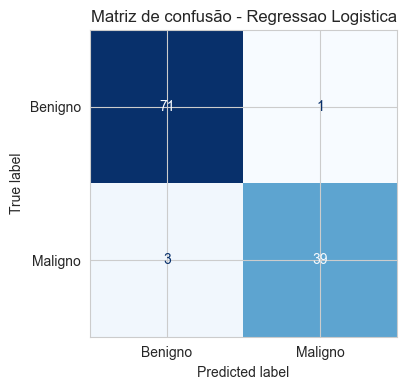

Modelo: KNN
Accuracy: 0.9561
Recall (Maligno): 0.9048
F1-score: 0.9383

Relatório de classificação:
              precision    recall  f1-score   support

     Benigno       0.95      0.99      0.97        72
     Maligno       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



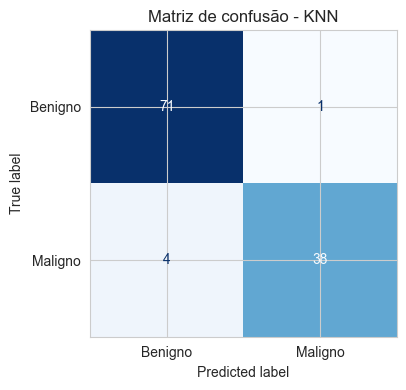

Modelo: Random Forest
Accuracy: 0.9737
Recall (Maligno): 0.9286
F1-score: 0.9630

Relatório de classificação:
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



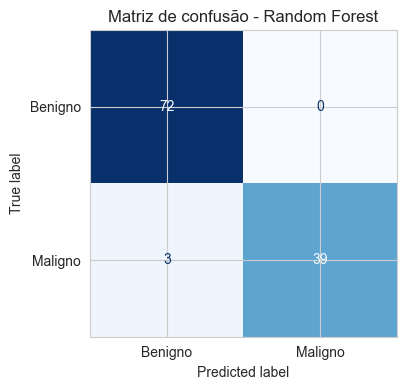

Comparativo consolidado dos modelos


,Modelo,Accuracy,Recall,F1
2,Random Forest,0.973684,0.928571,0.962963
0,Regressao Logistica,0.964912,0.928571,0.951220
1,KNN,0.956140,0.904762,0.938272


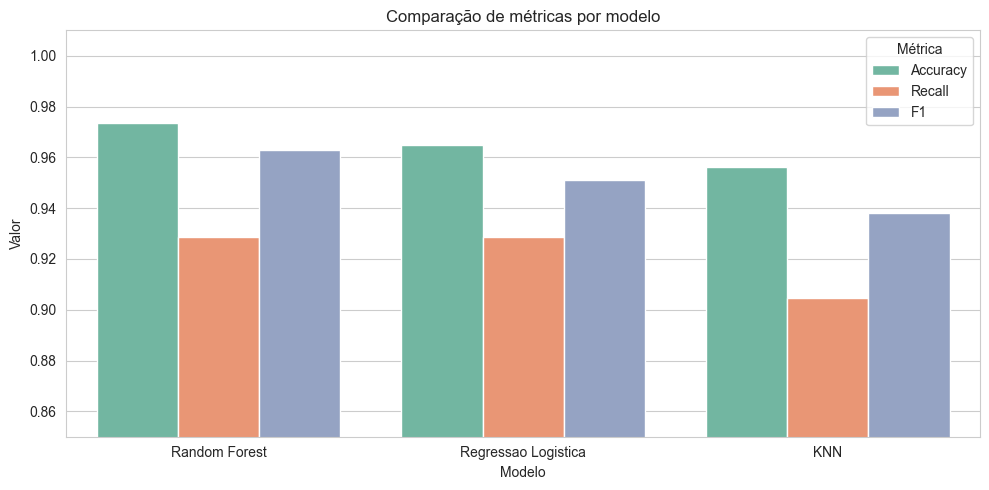

In [7]:
results = []
trained_models = {}
predictions = {}

for name, pipeline in pipelines.items():
    print("=" * 90)
    print(f"Modelo: {name}")

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    trained_models[name] = pipeline
    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    results.append({
        "Modelo": name,
        "Accuracy": acc,
        "Recall": rec,
        "F1": f1,
    })

    print(f"Accuracy: {acc:.4f}")
    print(f"Recall (Maligno): {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print()
    print("Relatório de classificação:")
    print(classification_report(y_test, y_pred, target_names=["Benigno", "Maligno"]))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benigno", "Maligno"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Matriz de confusão - {name}")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).sort_values(by=["Recall", "F1"], ascending=False)
print("=" * 90)
print("Comparativo consolidado dos modelos")
display(results_df)

results_long = results_df.melt(id_vars="Modelo", value_vars=["Accuracy", "Recall", "F1"], var_name="Métrica", value_name="Valor")
plt.figure(figsize=(10, 5))
sns.barplot(data=results_long, x="Modelo", y="Valor", hue="Métrica", palette="Set2")
plt.ylim(0.85, 1.01)
plt.title("Comparação de métricas por modelo")
plt.tight_layout()
plt.show()


## Visualização da Árvore de Decisão (plot_tree)

Como o Random Forest é composto por várias árvores, a figura abaixo mostra **uma árvore individual** da floresta. A profundidade foi limitada para melhorar a leitura visual.


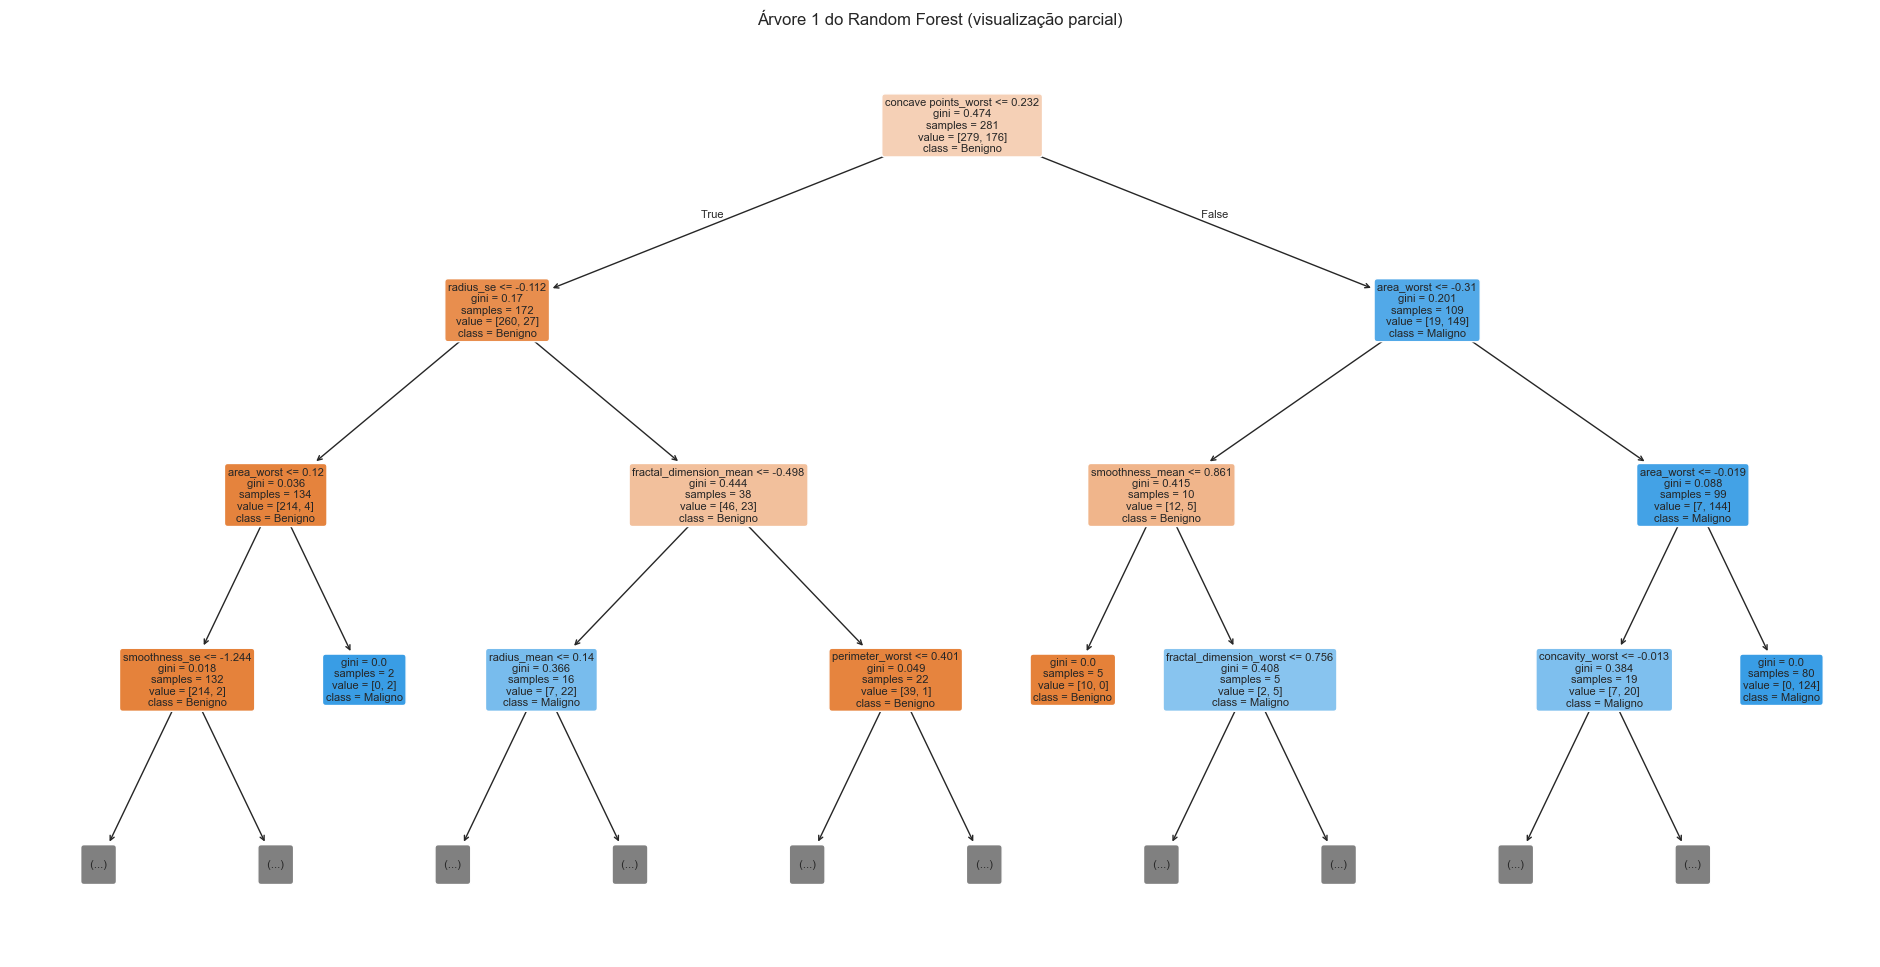

In [8]:
rf_pipeline = trained_models["Random Forest"]
rf_model = rf_pipeline.named_steps["model"]

plt.figure(figsize=(24, 12))
plot_tree(
    rf_model.estimators_[0],
    feature_names=numeric_features,
    class_names=["Benigno", "Maligno"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Árvore 1 do Random Forest (visualização parcial)")
plt.show()


## Escolha de Modelo e Leitura Crítica

A escolha final não deve ser orientada apenas por accuracy. Em triagem de saúde, é mais adequado priorizar o modelo com melhor capacidade de identificar casos malignos, por isso o recall da classe positiva tem maior peso na decisão. Mesmo com bom desempenho numérico, o uso prático deve ser de **apoio ao profissional de saúde**, nunca de substituição da avaliação médica.


In [9]:
best_model_name = results_df.iloc[0]["Modelo"]
print("Modelo com melhor combinacao de Recall e F1:", best_model_name)


Modelo com melhor combinacao de Recall e F1: Random Forest


## Importância das Variáveis

Para explicabilidade global, utiliza-se a importância de variáveis do Random Forest. Essa etapa ajuda a compreender quais atributos influenciam mais a classificação no conjunto de dados.


,importancia
perimeter_worst,0.143121
area_worst,0.142449
concave points_worst,0.112978
concave points_mean,0.088663
radius_worst,0.082649
radius_mean,0.061043
perimeter_mean,0.052928
area_mean,0.043820
concavity_mean,0.039761
area_se,0.032237


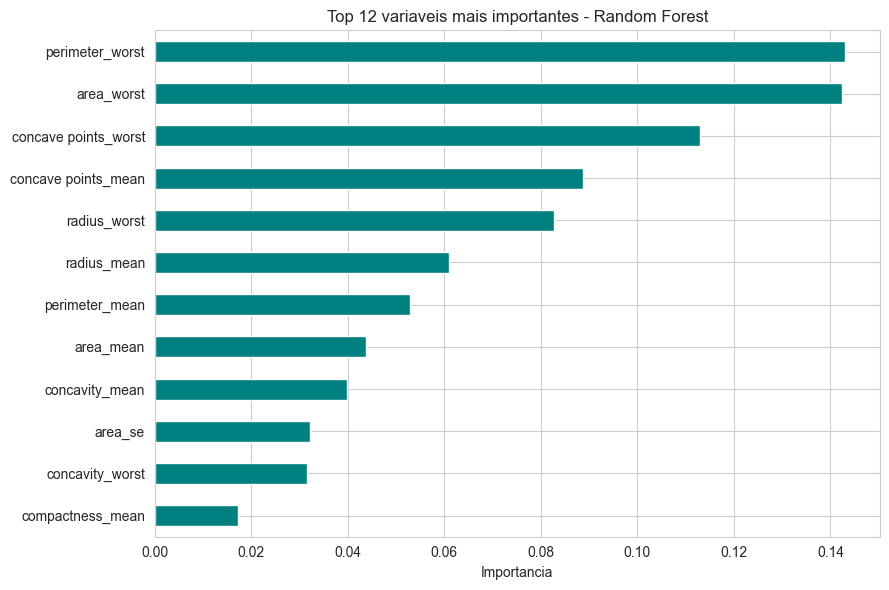

In [10]:
rf_pipeline = trained_models["Random Forest"]
rf_model = rf_pipeline.named_steps["model"]

feature_importance = pd.Series(rf_model.feature_importances_, index=numeric_features).sort_values(ascending=False)
display(feature_importance.head(12).to_frame("importancia"))

plt.figure(figsize=(9, 6))
feature_importance.head(12).sort_values().plot(kind="barh", color="teal")
plt.title("Top 12 variaveis mais importantes - Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


## SHAP para Explicabilidade

O SHAP é usado para ampliar a interpretabilidade do modelo. O **summary plot** mostra o efeito médio das variáveis na predição de malignidade, enquanto o **waterfall** detalha uma previsão individual, indicando como cada atributo contribui para aumentar ou reduzir o risco previsto.


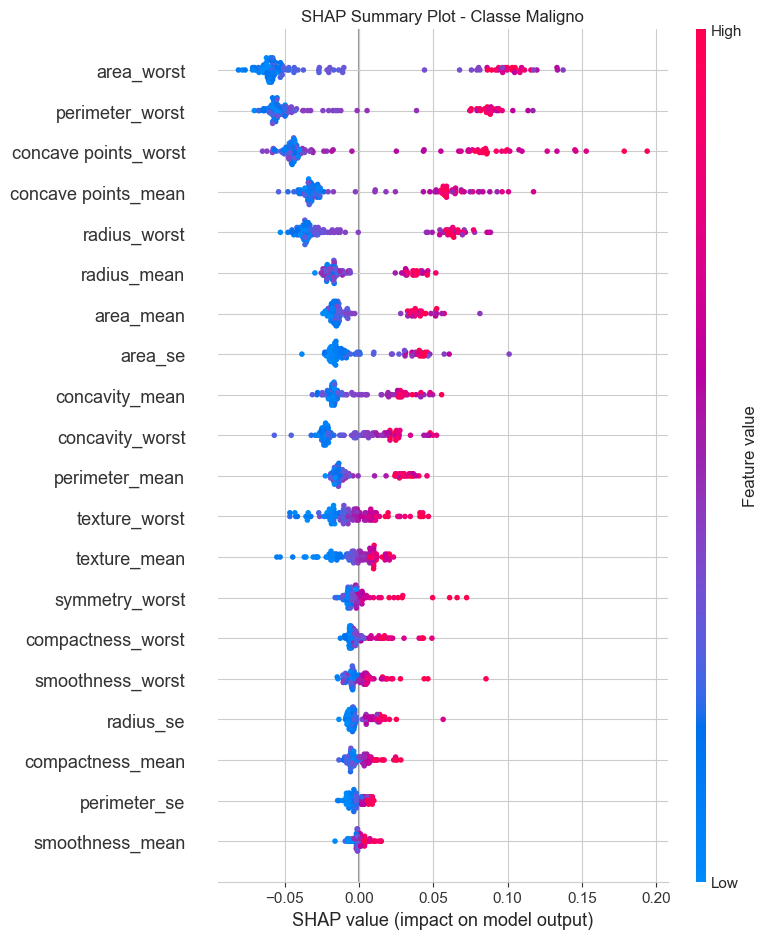

Probabilidade prevista de malignidade para o primeiro caso de teste: 0.0100


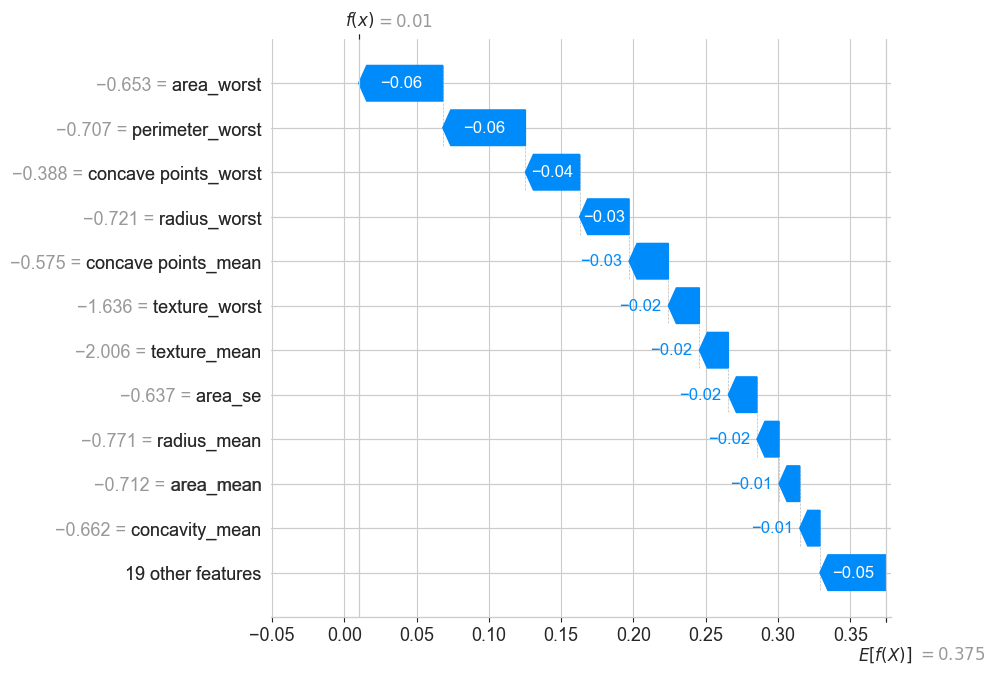

In [11]:
X_test_processed = rf_pipeline.named_steps["preprocess"].transform(X_test)
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()
X_test_processed = np.asarray(X_test_processed)

X_test_processed_df = pd.DataFrame(X_test_processed, columns=numeric_features, index=X_test.index)

explainer = shap.TreeExplainer(rf_model)
shap_values_raw = explainer.shap_values(X_test_processed)

def get_positive_shap_values(values):
    if isinstance(values, list):
        return values[1]
    arr = np.asarray(values)
    if arr.ndim == 3:
        return arr[:, :, 1]
    return arr

shap_values = get_positive_shap_values(shap_values_raw)

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_processed_df, show=False)
plt.title("SHAP Summary Plot - Classe Maligno")
plt.tight_layout()
plt.show()

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = np.array(expected_value)
    if expected_value.ndim > 0 and len(expected_value) > 1:
        expected_value = expected_value[1]
    else:
        expected_value = float(expected_value.ravel()[0])

sample_idx = 0
sample_prob_maligno = rf_pipeline.predict_proba(X_test.iloc[[sample_idx]])[0, 1]
print(f"Probabilidade prevista de malignidade para o primeiro caso de teste: {sample_prob_maligno:.4f}")

sample_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=expected_value,
    data=X_test_processed_df.iloc[sample_idx].values,
    feature_names=numeric_features,
)

shap.plots.waterfall(sample_explanation, max_display=12)


## Conclusão

O fluxo apresentado entrega uma base técnica consistente para um sistema inicial de suporte ao diagnóstico: dados explorados, pré-processamento estruturado, comparação entre modelos e explicabilidade. Na prática, esse tipo de abordagem pode apoiar a triagem, priorizando casos suspeitos para revisão mais rápida da equipe clínica. A decisão final, no entanto, deve permanecer com o médico, considerando histórico, exame físico e contexto da paciente.


## Simulação de Uso do Modelo

Nesta etapa final, é apresentado um exemplo prático de uso do modelo já treinado. Os valores de entrada são informados diretamente no código e, ao final, o sistema retorna a predição da classe (**Benigno** ou **Maligno**) junto com a probabilidade estimada de malignidade.


In [12]:
colunas_modelo = X.columns.tolist()

entrada_exemplo = pd.DataFrame([
    {
        "radius_mean": 17.99,
        "texture_mean": 10.38,
        "perimeter_mean": 122.80,
        "area_mean": 1001.0,
        "smoothness_mean": 0.11840,
        "compactness_mean": 0.27760,
        "concavity_mean": 0.3001,
        "concave points_mean": 0.14710,
        "symmetry_mean": 0.2419,
        "fractal_dimension_mean": 0.07871,
        "radius_se": 1.0950,
        "texture_se": 0.9053,
        "perimeter_se": 8.589,
        "area_se": 153.40,
        "smoothness_se": 0.006399,
        "compactness_se": 0.04904,
        "concavity_se": 0.05373,
        "concave points_se": 0.01587,
        "symmetry_se": 0.03003,
        "fractal_dimension_se": 0.006193,
        "radius_worst": 25.38,
        "texture_worst": 17.33,
        "perimeter_worst": 184.60,
        "area_worst": 2019.0,
        "smoothness_worst": 0.1622,
        "compactness_worst": 0.6656,
        "concavity_worst": 0.7119,
        "concave points_worst": 0.2654,
        "symmetry_worst": 0.4601,
        "fractal_dimension_worst": 0.11890,
    }
])

entrada_exemplo = entrada_exemplo[colunas_modelo]

modelo_final = trained_models[best_model_name]
predicao = int(modelo_final.predict(entrada_exemplo)[0])
prob_maligno = float(modelo_final.predict_proba(entrada_exemplo)[0, 1])

classe_prevista = "Maligno" if predicao == 1 else "Benigno"

print(f"Modelo utilizado nesta simulação: {best_model_name}")
print()
print("Valores de entrada informados:")
display(entrada_exemplo)
print(f"Resultado da predição: {classe_prevista}")
print(f"Probabilidade estimada de malignidade: {prob_maligno:.4f}")


Modelo utilizado nesta simulação: Random Forest

Valores de entrada informados:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189


Resultado da predição: Maligno
Probabilidade estimada de malignidade: 0.9533
